# Tercera sesión TFG - Simulaciones 

Lo primero que hicimos fue obtener los histogramas de los diferentes mapas de CMB (SMICA, Commander, NILC y SEVEM). Posteriormente buscamos la forma de pasar de los mapas en Q y U a E y B, así como un estudio por cuadrantes de la diferencia que esperábamos encontrar entre los distintos cuadrantes. Finalmente, usamos la asimetría para indicar la diferencia entre hemisferios estudiándolos para distintos planos.

Nos queda el último paso. Simular mapas de CMB y comprobar que lo obtenido se repite en las simulaciones.

La ruta a seguir consiste en recopilar los parámetros de $\Lambda CDM$, computar usando CAMB los coeficientes $C_\ell$ y utilizando la función de healpy `.synfast()` generar alrededor de 1000 simulaciones. aplicar la máscara a dichos mapas y obtener la asimetría con las funciones usadas hasta ahora.

In [1]:
# Carga de paquetes necesarios
import healpy as hp
import numpy as np
import scipy.stats as scs
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import camb as camb
from camb import model, initialpower
import FUNCIONES as FP
importlib.reload(FP)

<module 'FUNCIONES' from '/mnt/c/Users/Ariteirata/Documents/Grado - Física/Cosmología TFG/Notebooks/FUNCIONES.py'>

In [3]:
# Especificamos la máscara que vamos a usar
mask_P = hp.read_map('Mapas/MASK_CMB_POLARIZATION_2018.fits').astype(np.bool_)
mask_T = hp.read_map('Mapas/MASK_CMB_TEMPERATURE_2018.fits').astype(np.bool_)

## Breve introducción a CAMB y los parámetros característicos

Los 7 parámetros cosmológicos que caracterizan la geometría homogénea de fondo y su evolución:

- $\Omega_b h^2$ — **Densidad física de bariones**  
  Cantidad de materia bariónica (protones y neutrones) por unidad de volumen comóvil, escalada por $h^2$. Controla la altura relativa de los picos acústicos en el espectro $C_\ell$.

- $\Omega_c h^2$ — **Densidad física de materia oscura fría (CDM)**  
  Determina la profundidad de los potenciales gravitatorios primordiales y afecta la posición y amplitud de los picos acústicos.

- $\theta_s$ — **Tamaño angular del horizonte acústico**  
  Ángulo subtendido por el horizonte sonoro en recombinación. Fija la escala característica de los picos acústicos en el espectro.

- $\tau$ — **Profundidad óptica de reionización**  
  Mide la cantidad de dispersión Thomson que sufrieron los fotones del CMB durante la reionización. Suaviza el espectro a altas $\ell$.

- $A_s$ — **Amplitud del espectro primordial de perturbaciones escalares**  
  Normaliza la potencia de las fluctuaciones primordiales generadas durante la inflación.

- $n_s$ — **Índice espectral de las perturbaciones escalares**  
  Describe la dependencia en escala del espectro primordial. Indica cuán cerca está de la invariancia de escala (valor cercano a 1).

- $H_0$ *o* $\Omega_\Lambda$ — **Parámetro de Hubble actual** *o* **densidad de energía oscura**  
  Según la parametrización, se usa uno u otro. Determinan la tasa de expansión actual y la contribución de la energía oscura al contenido total del Universo;

Dichos parámetros los descargamos directamente de https://pla.esac.esa.int/#cosmology, en la sección de *cosmology*, en la parte de *CMB angular power spectra*.

In [26]:
# Vamos a leer el archivo .txt que contiene la información de los parámetros cosmológicos. Para ello usamos
# with
with open('Parámetros CAMB.txt', 'r', encoding='utf-8') as parametros:
    print(parametros.read())

 -log(Like) =    1387.31682794604
  chi-sq    =    2774.63365589209

    1  0.2238280E-01   omegabh2              \Omega_b h^2
    2  0.1201075E+00   omegach2              \Omega_c h^2
    3  0.1040909E+01   theta                 100\theta_{MC}
    4  0.5430842E-01   tau                   \tau
   17  0.3044784E+01   logA                  {\rm{ln}}(10^{10} A_s)
   18  0.9660499E+00   ns                    n_s
   25  0.1000442E+01   calPlanck             y_{\rm cal}
   26  0.4605402E+02   acib217               A^{CIB}_{217}
   28  0.6567009E+00   xi                    \xi^{tSZ-CIB}
   29  0.7083803E+01   asz143                A^{tSZ}_{143}
   30  0.2482123E+03   aps100                A^{PS}_{100}
   31  0.5067985E+02   aps143                A^{PS}_{143}
   32  0.5330959E+02   aps143217             A^{PS}_{143\times217}
   33  0.1218608E+03   aps217                A^{PS}_{217}
   34  0.3846930E-02   aksz                  A^{kSZ}
   35  0.8802494E+01   kgal100               A^{{\rm dust}TT

## Generación de los coeficientes $C_\ell$

Utilizamos ahora la función `.set_params()` de CAMB para registrar los parámetros obtenidos del modelo $\Lambda CDM$ y generar así "nuestro universo". Posteriormente obtenemos los resultados de la evolución del universo generado con `.get_results()`. 

A partir de esto especificamos el modelo de inflación cósmica y le asignmaos los valores físicos correspondientes.

Finalmente extraemos los coeficientes $C_\ell$ y los guardamos para no tener que calcularlos de nuevo.

In [ ]:
# Generamos pues con los datos del archivo 'Parámetros CAMB.txt' nuestro universo. 
# Específicamos también el valor de ell máximo

lmax = 5000
params = camb.set_params(H0=0.6732117E+02, 
                         ombh2=0.2238280E-01, 
                         omch2=0.1201075E+00, 
                         mnu=0.6000000E-01, 
                         omk=0.0000000E+00, 
                         tau=0.5430842E-01,  
                         As=2.100549E-9, 
                         ns=0.9660499E+00, 
                         halofit_version='mead', 
                         lmax=lmax)

params.set_for_lmax(lmax, lens_potential_accuracy=2)
params.WantTensors = True

# Obtenemos ahora los resultados antes de introducir los parámetros de inflación
resultados = camb.get_results(params)

# Añadimos los parámetros de inflación
params_inflacion = initialpower.InitialPowerLaw()
params_inflacion.set_params(ns=0.9660499E+00, r=0.0000000E+00)
resultados.power_spectra_from_transfer(params_inflacion)

# Obtenemos ahora los coeficientes Cl
Cl = resultados.get_total_cls(lmax, CMB_unit='uK', raw_cl = True)

# Y los guardamos para usarlos en el futuro
ell_y_cell = np.append(np.arange(np.size(Cl[:,0])), Cl.transpose().ravel())
ell_y_cell = ell_y_cell.reshape((5,5001))
np.savetxt("Cl_simulaciones.dat", ell_y_cell.transpose())

El archivo generado contiene cinco columnas. La primera se corresponde con el multipolo ($\ell$); la segunda columna se corresponde con los coeficientes $C_\ell^{TT}$; la tercera con los $C_\ell^{EE}$; la cuarta con los $C_\ell^{BB}$; y la quinta con el término cruzado $C_\ell^{EB}$;

## Generación de los mapas de CMB simulados

Si indicamos el valor de nside, $\ell$max, así como los coeficientes $C_\ell$, obtendremos un mapa simulado de CMB usando la función `.synfast()`.

In [47]:
# Primero leemos el archivo donde tenemos los coeficientes Cl:
datos = pd.read_csv('Cl_simulaciones.dat', sep = r'\s+', header = None)

# La columna cero corresponde a los ell y la primera a los Cl.
ell = datos[0]
ClTT = datos[1]
ClEE = datos[2]
ClBB = datos[3]
ClEB = datos[4]

cls_completo = [ClTT, ClEE, ClBB, ClEB]

In [48]:
# Obtenemos las simulaciones con synfast, indicando el nside

nside = 2048
mapa_T, mapa_Q, mapa_U = hp.synfast(cls_completo, nside=nside, lmax=lmax, new=True)

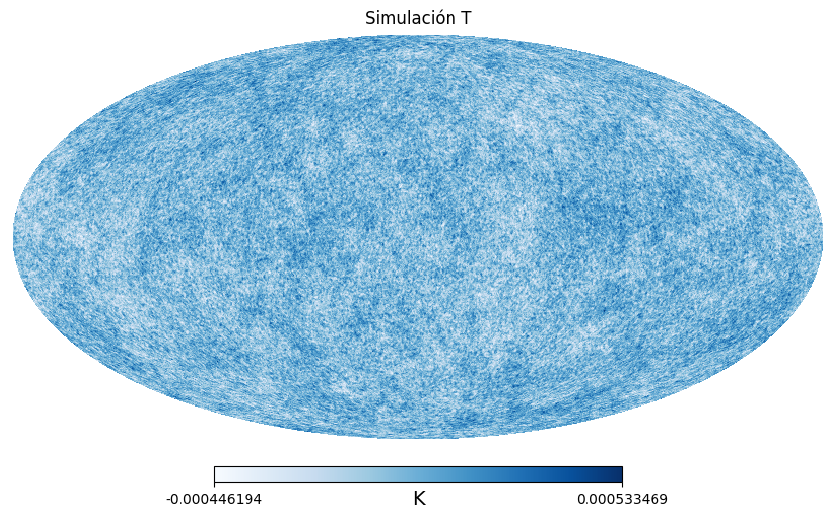

In [ ]:
hp.mollview(mapa_T, 
            title = "Simulación T", 
            unit = r"\muK", 
            cmap="Blues")

Viendo que funciona, vamos a automatizarlo para obtener 1000 simulaciones, aplicarles la máscara del plano galáctico y obtener la asimetría. Partimos de la función `ASIMETRIA_PLANO()`

In [59]:
def ASIMETRIA_SIMULACION(cls, nside, lmax, num_sim, mask_gal, theta, phi):
    'Obtenemos n simulaciones y calculamos la asimetría respecto a un plano dado'
    'por theta y phi'

    # Lo primero es reducir la máscara tanto como nos indique el nside, ya que originalmente
    # está hecha para nside = 2048.
    mask_gal_ajustada = hp.ud_grade(mask_gal.astype(float), nside)
    mask_gal_ajustada = mask_gal_ajustada > 0.99   

    # Guardamos los píxeles válidos para usarlos directamente dentro del bucle.
    pixeles_validos = np.logical_not(mask_gal_ajustada)

    # Obtenemos los ángulos esféricos (theta: colatitud, phi: longitud) de cada píxel.
    npix = hp.nside2npix(nside)
    theta_r, phi_r = hp.pix2ang(nside, np.arange(npix))

    # Obtenemos los vectores de posición r tal que al hacer el producto 
    # escalar de dichos vectores con el del plano obtendremos si estamos 
    # situados en el "norte" o el "sur".
    r = np.column_stack([np.sin(theta_r) * np.cos(phi_r),
                         np.sin(theta_r) * np.sin(phi_r),
                         np.cos(theta_r)])

    # Aplicamos al máscara galáctica ajustada.
    r = r[pixeles_validos, :]
    
    # Obtenemos el vector del plano y regiones fuera del bucle
    x = np.sin(np.radians(theta)) * np.cos(np.radians(phi))
    y = np.sin(np.radians(theta)) * np.sin(np.radians(phi))
    z = np.cos(np.radians(theta))
    n = np.array([x, y, z])
    
    prod_escalar = r @ n
    norte = (prod_escalar > 0)    
    sur = ~norte   

    # Iniciamos la variable de iteración i:
    i = 0

    # Generamos un array donde iremos guardando la asimetría de cada mapa.
    asimetria = []
    
    for i in range(num_sim):
        
        # Tomando los cls obtenidos previamente, y el valor del nside obtenemos tantas simulaciones
        # como estén indicadas en num_sim.
        mapa_T, mapa_Q, mapa_U = hp.synfast(cls, nside=nside, lmax=lmax, new=True)

        # Extraemos directamente los datos válidos (aplicando la máscara galáctica) a los mapas de 
        # T, Q y U.
        mapa_Txx = mapa_T[pixeles_validos]
        mapa_Qxx = mapa_Q[pixeles_validos]
        mapa_Uxx = mapa_U[pixeles_validos]

        # Obtenemos las sigmas totales de cada mapa.
        sigma_total_T = np.var(mapa_Txx)
        sigma_total_Q = np.var(mapa_Qxx)     
        sigma_total_U = np.var(mapa_Uxx)
        
        # Obtenemos finalmente la varianza del norte y del sur para cada
        # mapa T, Q o U.
        sigma_norte_T = np.var(mapa_Txx[norte])
        sigma_sur_T = np.var(mapa_Txx[sur])
        asimetria_T = (sigma_norte_T - sigma_sur_T) / sigma_total_T   

        sigma_norte_Q = np.var(mapa_Qxx[norte])
        sigma_sur_Q = np.var(mapa_Qxx[sur])
        asimetria_Q = (sigma_norte_Q - sigma_sur_Q) / sigma_total_Q

        sigma_norte_U = np.var(mapa_Uxx[norte])
        sigma_sur_U = np.var(mapa_Uxx[sur])
        asimetria_U = (sigma_norte_U - sigma_sur_U) / sigma_total_U 

        # Anexamos estas asimetrías al array asimetría.
        asimetria.append([asimetria_T, asimetria_Q, asimetria_U])

    # - - - - - - - - - - - - - - - - - - - - - - - - - - - - #
    return np.array(asimetria)

In [65]:
asimetria_simulacion = ASIMETRIA_SIMULACION(cls_completo, 1024, 2000, 1000, mask, 0, 0)

In [66]:
asimetria_simulacion

array([[ 0.07635787, -0.00396767, -0.00594053],
       [-0.03251138,  0.00844279,  0.00219793],
       [-0.08333051,  0.0006755 , -0.00067071],
       ...,
       [-0.03142206, -0.00613291, -0.00331666],
       [-0.07440808, -0.00771875,  0.0057758 ],
       [-0.02574139, -0.00665376,  0.00114309]], shape=(1000, 3))

In [67]:
np.savetxt(
    "asimetrias_simulacion.txt", 
    asimetria_simulacion, 
    header="Asimetria_T  Asimetria_Q  Asimetria_U", 
    comments=""
)